# Flight Delay Analysis: Python Exploration
Exploring whether flight distance affects departure delay, using a 100K-flight sample (2019-2023).

In [2]:
import pandas as pd
df=pd.read_csv('/content/flights_sample_100k.csv')
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-03-01,Allegiant Air,Allegiant Air: G4,G4,20368,1668,PGD,"Punta Gorda, FL",SPI,"Springfield, IL",...,0.0,160.0,138.0,122.0,994.0,NaN,NaN,NaN,NaN,NaN
1,2021-02-16,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,2437,DFW,"Dallas/Fort Worth, TX",LAX,"Los Angeles, CA",...,0.0,211.0,NaN,NaN,1235.0,NaN,NaN,NaN,NaN,NaN
2,2022-04-12,PSA Airlines Inc.,PSA Airlines Inc.: OH,OH,20397,5560,EWN,"New Bern/Morehead/Beaufort, NC",CLT,"Charlotte, NC",...,0.0,79.0,78.0,51.0,221.0,NaN,NaN,NaN,NaN,NaN
3,2021-10-13,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1944,ABQ,"Albuquerque, NM",DEN,"Denver, CO",...,0.0,80.0,71.0,49.0,349.0,10.0,0.0,0.0,0.0,6.0
4,2022-06-05,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,3081,PIT,"Pittsburgh, PA",STL,"St. Louis, MO",...,0.0,105.0,100.0,82.0,554.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   FL_DATE                  100000 non-null  object 
 1   AIRLINE                  100000 non-null  object 
 2   AIRLINE_DOT              100000 non-null  object 
 3   AIRLINE_CODE             100000 non-null  object 
 4   DOT_CODE                 100000 non-null  int64  
 5   FL_NUMBER                100000 non-null  int64  
 6   ORIGIN                   100000 non-null  object 
 7   ORIGIN_CITY              100000 non-null  object 
 8   DEST                     100000 non-null  object 
 9   DEST_CITY                100000 non-null  object 
 10  CRS_DEP_TIME             100000 non-null  int64  
 11  DEP_TIME                 97424 non-null   float64
 12  DEP_DELAY                97423 non-null   float64
 13  TAXI_OUT                 97382 non-null   float64
 14  WHEEL

In [ ]:
	## Q. Does flight distance affect delay?

correlation = df['DISTANCE'].corr(df['DEP_DELAY'])
print(round(correlation,3))

0.018


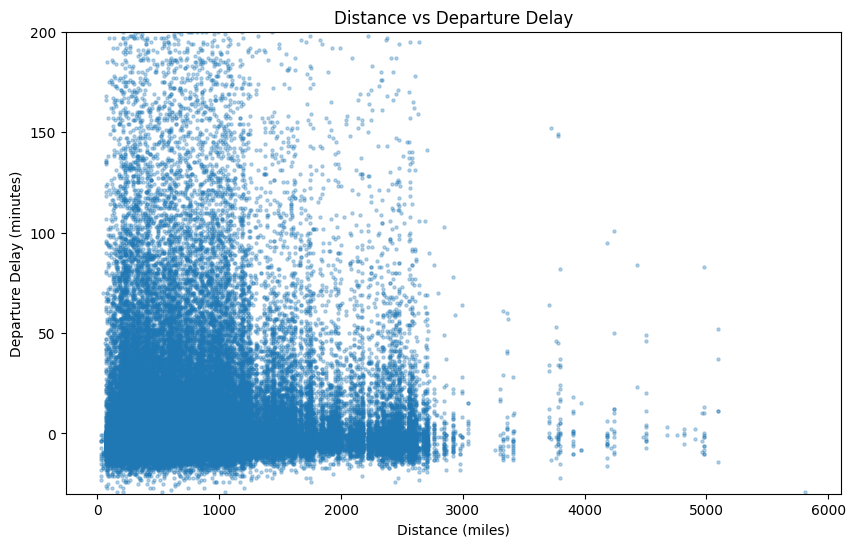

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df['DISTANCE'], df['DEP_DELAY'], alpha=0.3, s=5)
plt.xlabel('Distance (miles)')
plt.ylabel('Departure Delay (minutes)')
plt.title('Distance vs Departure Delay')
plt.ylim(-30, 200)
plt.show()

Flight distance has a very weak relationship with departure delay (correlation 0.018). The scatter plot shows no clear pattern.

In [ ]:
## Q. Average vs median delay (operated flights only)

ops = df[df['CANCELLED'] == 0].copy()
print("Average delay:", round(ops['DEP_DELAY'].mean(), 2))
print("Median delay:", ops['DEP_DELAY'].median())

Average delay: 10.14
Median delay: -2.0


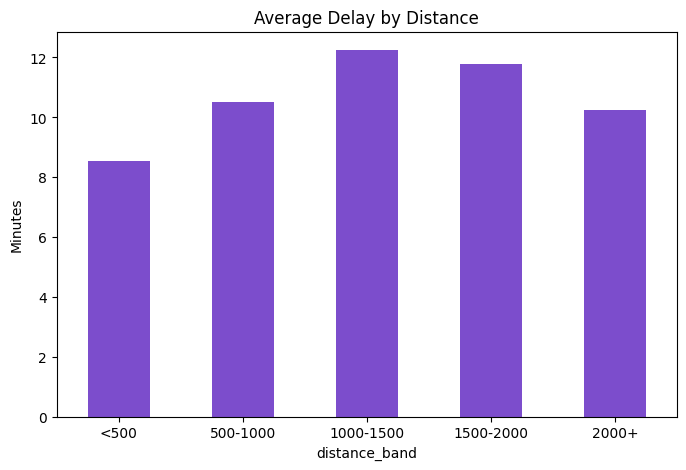

In [ ]:
## Q. Average delay by distance band


ops['distance_band'] = pd.cut(ops['DISTANCE'], [0, 500, 1000, 1500, 2000, 6000],
                              labels=['<500', '500-1000', '1000-1500', '1500-2000', '2000+'])
avg = ops.groupby('distance_band', observed=True)['DEP_DELAY'].mean()
avg.plot(kind='bar', figsize=(8, 5), color='#7C4DCC')
plt.title('Average Delay by Distance')
plt.ylabel('Minutes')
plt.xticks(rotation=0)
plt.show()

Most flights (66%) leave on time or early (median -2 minutes). Only about 6% are delayed by more than an hour, but these long delays pull the average up to 10 minutes. Distance has a very weak relationship with delay